In [64]:
from sklearn import datasets
from sklearn import model_selection as skms
%matplotlib inline
diabetes = datasets.load_diabetes()
d_tts = skms.train_test_split(diabetes.data,
                              diabetes.target,
                              test_size=.25,
                              random_state=42)
(diabetes_train_ftrs, diabetes_test_ftrs,
 diabetes_train_tgt,  diabetes_test_tgt) = d_tts

In [65]:
import numpy as np
weights = np.array([3.5, -2.1, .7])
print(np.sum(np.abs(weights)),
      np.sum(weights**2))

6.3 17.15


In [66]:
def rdot(arr,brr):
    return np.dot(brr,arr)
x_1 = np.arange(10) # vektor: [0, 1, 2, ..., 9]
m, b = 3, 2 # vektor: [0, 1, 2, ..., 9]
w = np.array([m,b])
x = np.c_[x_1, np.repeat(1.0, 10)] # the plus-one trick
print(w)
print(x)
print(x.T)
errors = np.tile(np.array([0.0, 1.0, 1.0, .5, .5]), 2)
print(errors * errors)
print(np.dot(errors, errors))

#y_true = rdot(w,x)
y_true = np.dot(w,x.T)
y_msr  = y_true + errors
print(y_true)
print(y_msr)

D = (x,y_msr)

[3 2]
[[0. 1.]
 [1. 1.]
 [2. 1.]
 [3. 1.]
 [4. 1.]
 [5. 1.]
 [6. 1.]
 [7. 1.]
 [8. 1.]
 [9. 1.]]
[[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
[0.   1.   1.   0.25 0.25 0.   1.   1.   0.25 0.25]
5.0
[ 2.  5.  8. 11. 14. 17. 20. 23. 26. 29.]
[ 2.   6.   9.  11.5 14.5 17.  21.  24.  26.5 29.5]


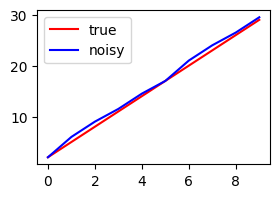

In [70]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1,figsize=(3,2))
ax.plot(x_1, y_true, 'r', label='true')
ax.plot(x_1, y_msr , 'b', label='noisy')
ax.legend();

In [71]:
def sq_diff(a,b):
    return (a-b)**2
predictions = rdot(w,x)
np.sum(sq_diff(predictions, y_msr))

np.float64(5.0)

In [72]:
predictions = rdot(w,x)

loss = np.sum(sq_diff(predictions, y_msr))

complexity_1 = np.sum(np.abs(weights))
complexity_2 = np.sum(weights**2) # == np.dot(weights, weights)
print(complexity_1)
print(complexity_2)
print(loss)
cost_1 = loss + complexity_1
cost_2 = loss + complexity_2

print("Sum(abs) complexity:", cost_1)
print("Sum(sqr) complexity:", cost_2)

6.3
17.15
5.0
Sum(abs) complexity: 11.3
Sum(sqr) complexity: 22.15


In [32]:
predictions = rdot(w,x)
errors = np.sum(sq_diff(predictions, y_msr))
complexity_1 = np.sum(np.abs(weights))

C = .5
cost = errors + C * complexity_1
cost

np.float64(8.15)

In [73]:
models = [linear_model.Lasso(),            # L1 regularizirana; C=1.0
          linear_model.Ridge()]            # L2 regularizirana; C=1.0

for model in models:
    model.fit(diabetes_train_ftrs, diabetes_train_tgt)
    train_preds = model.predict(diabetes_train_ftrs)
    test_preds  = model.predict(diabetes_test_ftrs)
    print(get_model_name(model),
          "\nTrain MSE:",metrics.mean_squared_error(diabetes_train_tgt,
                                                    train_preds),
          "\n Test MSE:", metrics.mean_squared_error(diabetes_test_tgt,
                                                     test_preds))

Lasso 
Train MSE: 3947.9053297148935 
 Test MSE: 3433.155492119971
Ridge 
Train MSE: 3461.743744823801 
 Test MSE: 3105.4721464484733
